# Auto-Encoder for Colorization

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

import os
import pathlib
from PIL import Image
import skimage
from tqdm import tqdm


# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, './util')
import vcpi_util

print(torch.__version__)

2.2.1+cu118


In [71]:
def train(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {}

    history['val_loss'] = []
    history['loss'] = []
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, targets,classes,_) in tqdm(enumerate(train_loader, 0)):
            
            inputs = inputs.to(device)
            targets = targets.to(device)
    
            outputs = model(inputs)
    
            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.cpu().detach().numpy()
     
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for i,t,_,_ in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                
                #with torch.no_grad():
                val_loss += loss_fn(o, t).cpu().detach().numpy()


        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Val Loss: {val_loss:0.6f}; Elapsed time: {(stop_time - start_time):0.4f}')

        history['val_loss'].append(val_loss)
        history['loss'].append(epoch_loss)
 
        ###### Saving ######
        if val_loss < best_val_loss:
           
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'history': history,
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}_best.pt')
            best_val_loss = val_loss

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)


class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False
    
from matplotlib import colors

def plot_scatter(x,y,targets, lims = None):
    cmap = colors.ListedColormap(['black', 'darkred', 'darkblue', 
                                  'darkgreen', 'yellow', 'brown', 
                                  'purple', 'lightgreen', 'red', 'lightblue'])
    bounds=[0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5,8.5,9.5]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    if lims != None:
        s = 50
    else: s = 1

    plt.figure(figsize=(10,10))
    plt.scatter(x, y, c = targets, cmap=cmap, s = s, norm=norm)
    plt.colorbar()
    if lims != None:
         plt.xlim(lims[0], lims[2])
         plt.ylim(lims[1], lims[3])

    plt.show()


def show_preds(set1, set2, set3, classes, count):
  
    columns = 5
    rows = count + 1  
    plt.figure(figsize=(count, .5 * rows * columns))
  
    for n in range(count):
        ax = plt.subplot(rows, columns, n*columns+1)
        plt.title(classes[n])
        plt.imshow(np.transpose(set1[n].numpy(), (1,2,0)), cmap=plt.cm.gray, vmin=-1, vmax=1)
        plt.axis('off')
        ax = plt.subplot(rows, columns, n*columns+2)
        plt.title("A")
        plt.imshow(np.transpose(set2[n].numpy(), (1,2,0))[:,:,0], cmap=plt.cm.gray, vmin=-1, vmax=1)
        plt.axis('off')
        ax = plt.subplot(rows, columns, n*columns+3)
        plt.title("B")
        plt.imshow(np.transpose(set2[n].numpy(), (1,2,0))[:,:,1], cmap=plt.cm.gray, vmin=-1, vmax=1)
        plt.axis('off')
        ax = plt.subplot(rows, columns, n*columns+4)
        plt.title("RGB")
        lab = np.stack(
            [
            (np.transpose(set1[n].numpy(), (1,2,0))[:,:,0] * 50 + 50), 
            (np.transpose(set2[n].numpy(), (1,2,0))[:,:,0] * 127),
            (np.transpose(set2[n].numpy(), (1,2,0))[:,:,1] * 127)
            ], 
            axis = 2)

        rgb = skimage.color.lab2rgb(lab)
        plt.imshow(rgb)
        plt.axis('off')

        ax = plt.subplot(rows, columns, n*columns+5)
        plt.title("Original")
        plt.imshow(set3[n].numpy())
        plt.axis('off')   

def show_images(set1, set2, original, classes, count):
  
  columns = 4
  rows = count + 1  
  plt.figure(figsize=(count, 0.5 * columns * rows))
  
  for n in range(count):
    ax = plt.subplot(rows, columns, n*columns+1)
    plt.title(classes[n])
    plt.imshow(np.transpose(set1[n].numpy(), (1,2,0)), cmap=plt.cm.gray, vmin=-1, vmax=1)
    plt.axis('off')
    ax = plt.subplot(rows, columns, n*columns+2)
    plt.title("A")
    plt.imshow(np.transpose(set2[n].numpy(), (1,2,0))[:,:,0], cmap=plt.cm.gray, vmin=-1, vmax=1)
    ax = plt.subplot(rows, columns, n*columns+3)
    plt.title("B")
    plt.imshow(np.transpose(set2[n].numpy(), (1,2,0))[:,:,1], cmap=plt.cm.gray, vmin=-1, vmax=1)
    plt.axis('off')              
    ax = plt.subplot(rows, columns, n*columns+4)
    plt.title("Original")
    plt.imshow(original[n].numpy())
    plt.axis('off')   


# Configuration

In [3]:
HEIGHT = 256
WIDTH = 256
NUM_CHANNELS = 3
BATCH_SIZE = 32
LATENT_SPACE_DIM = 128

MODEL_PATH = 'autoencoder_colorization_models'

# defines if training, or using already pre-trained models. Set to TRUE in the first run 
# of this notebook, and FALSE for subsequent runs
TRAIN = True

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cuda:0


# Lab Color Space

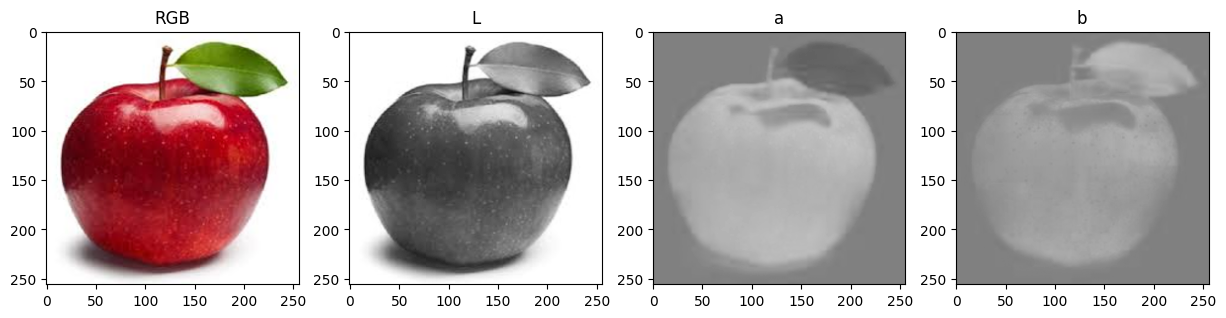

In [4]:
def showLAB(filename):
    
    img = Image.open(filename).resize([WIDTH, HEIGHT]).convert('RGB')
    LAB = skimage.color.rgb2lab(np.array(img)).astype(np.float32)
    plt.figure(figsize=(15, 60))
    ax = plt.subplot(1,4,1)
    plt.imshow(img)
    plt.title("RGB")
    ax = plt.subplot(1,4,2)
    plt.title("L")
    plt.imshow(LAB[:,:,0], cmap='gray', vmin=0, vmax=100)
    ax = plt.subplot(1,4,3)
    plt.title("a")
    plt.imshow(LAB[:,:,1], cmap='gray', vmin=-128, vmax=127)
    ax = plt.subplot(1,4,4)
    plt.title("b")
    plt.imshow(LAB[:,:,2], cmap='gray', vmin=-128, vmax=127)

showLAB( f'data/NCD/Color/Apple/Apple3.jpg')    

# Create Dataset

In [39]:
class CustomDataLoader(torch.utils.data.Dataset):

    def __init__(self, path, transform = None):
        super().__init__()
        
        self.path = path

        self.transform = transform
        self.classes = [x.name for x in os.scandir(path) if x.is_dir()]
        self.classes_to_idx = {cls_name:i for i, cls_name in enumerate(self.classes)}
        self.paths = list(pathlib.Path(path,).glob('*/*.jpg'))
        self.data = []
        self.labels = []
        for p in self.paths:
           
                img = Image.open(p).resize([WIDTH, HEIGHT]).convert('RGB')
                class_name  = p.parent.name
                lab = skimage.color.rgb2lab(np.array(img)).astype(np.float32)

                l = (lab[:, :, 0:1]/50.0) - 1   # (H, W, 1)
                ab = lab[:, :, 1:]/127.0   # (H, W, 2)

                self.data.append([l, ab, class_name, np.array(img)])

    def __len__(self):

        return len(self.paths)    

    def __getitem__(self, idx):

        dat = self.data[idx]
        return self.transform(dat[0]), self.transform(dat[1]), dat[2] , dat[3]


In [40]:
transform = transforms.Compose(
    [transforms.ToTensor()]) 

dataset = CustomDataLoader('data/NCD/Color', transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size 

train_set, val_set, test_set = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE, shuffle=True)

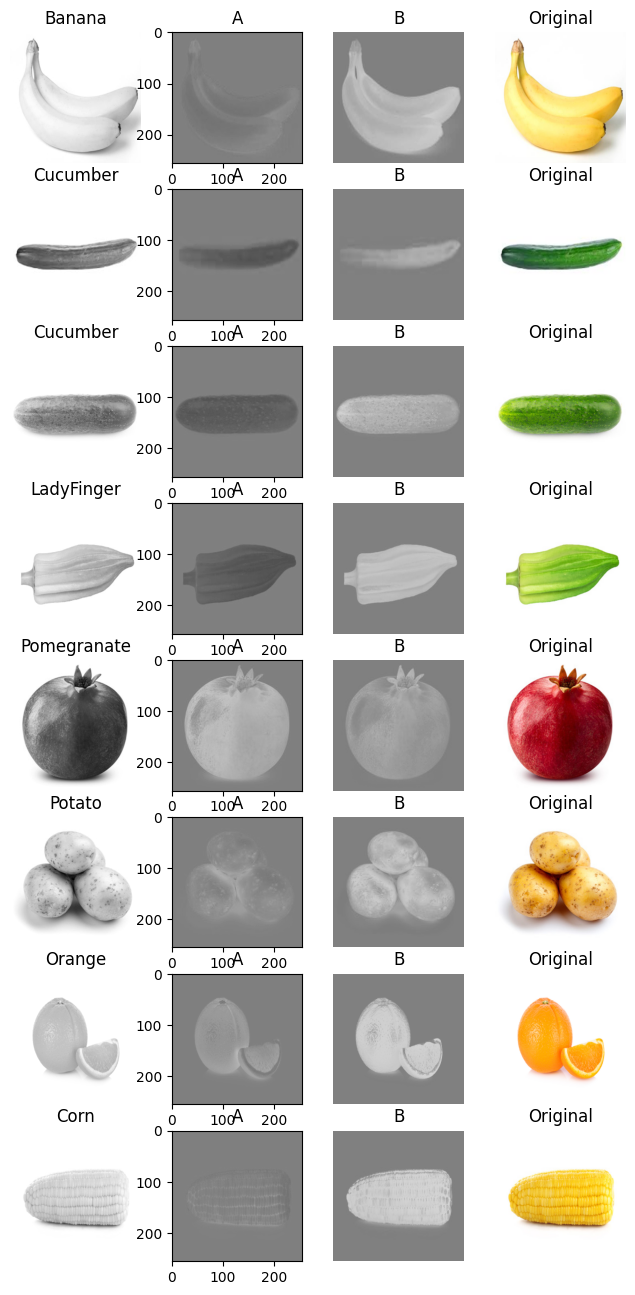

In [72]:
gray, AB, classes, original = next(iter(train_loader))

show_images(gray,AB, original, classes, 8)


In [8]:
class Conv_Block(nn.Module):

    def __init__(self, in_channels, out_channels):
        
        super().__init__()

        self.convBlock = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding = 1, stride = 2), 
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )


    def forward(self, x):
        return self.convBlock(x)      
   

class Up_Conv_Block(nn.Module):
    
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upConvBlock = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size= 3, stride = 2, padding=1, output_padding = 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )


    def forward(self, x):
        return self.upConvBlock(x)      


class AutoEncoder(torch.nn.Module):

    def __init__(self, latent_space_dim):
        super().__init__()

        # encoder layers
        self.cb1 = Conv_Block(1,32) # 128x128
        self.cb2 = Conv_Block(32,64) # 64x64      
        self.cb3 = Conv_Block(64,128) # 32x32
        self.cb4 = Conv_Block(128,256) # 16x16      
        self.cb5 = Conv_Block(256,512) # 8x8      

        self.efc1 = torch.nn.Linear(512*8*8, latent_space_dim)

        #decoder layers

        self.dfc1 = torch.nn.Linear(latent_space_dim, 512*8*8)

        self.ub1 = Up_Conv_Block(512, 256)
        self.ub2 = Up_Conv_Block(256, 128)
        self.ub3 = Up_Conv_Block(128, 64)
        self.ub4 = Up_Conv_Block(64, 32)

        self.dconvT2 = torch.nn.ConvTranspose2d(in_channels = 32, out_channels = 2, kernel_size= 3, stride = 2, 
                                                padding = 1, output_padding = 1)
        self.dsig = torch.nn.Sigmoid()

    def encoder(self, x):

        x = self.cb1(x)
        x = self.cb2(x)
        x = self.cb3(x)
        x = self.cb4(x)
        x = self.cb5(x)

        x = torch.flatten(x, 1)
        x = self.efc1(x)

        return x
        
    def decoder(self,x):

        x = self.dfc1(x)
        x = x.reshape(-1, 512, 8, 8)
        x = self.ub1(x)
        x = self.ub2(x)
        x = self.ub3(x)
        x = self.ub4(x)
        x = self.dconvT2(x)
        return x

    def forward(self,x):

        encoded = self.encoder(x)
        output = self. decoder(encoded)
        return output   

In [34]:
AE = AutoEncoder(256)
AE.to(device)
torchinfo.summary(AE, input_size=(BATCH_SIZE, 1, 256, 256))

Layer (type:depth-idx)                   Output Shape              Param #
AutoEncoder                              [32, 2, 256, 256]         --
├─Conv_Block: 1-1                        [32, 32, 128, 128]        --
│    └─Sequential: 2-1                   [32, 32, 128, 128]        --
│    │    └─Conv2d: 3-1                  [32, 32, 128, 128]        320
│    │    └─BatchNorm2d: 3-2             [32, 32, 128, 128]        64
│    │    └─ReLU: 3-3                    [32, 32, 128, 128]        --
├─Conv_Block: 1-2                        [32, 64, 64, 64]          --
│    └─Sequential: 2-2                   [32, 64, 64, 64]          --
│    │    └─Conv2d: 3-4                  [32, 64, 64, 64]          18,496
│    │    └─BatchNorm2d: 3-5             [32, 64, 64, 64]          128
│    │    └─ReLU: 3-6                    [32, 64, 64, 64]          --
├─Conv_Block: 1-3                        [32, 128, 32, 32]         --
│    └─Sequential: 2-3                   [32, 128, 32, 32]         --
│    │   

In [35]:
if TRAIN:
    opt = torch.optim.Adam(AE.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', 
                                                               factor = 0.1, patience=3)
    loss_fn = torch.nn.loss_fn = torch.nn.MSELoss()
    early_stop = Early_Stopping(9)
        
    history=train(AE, train_loader, val_loader, 100, loss_fn, opt,  scheduler, early_stop, 
                      f'{MODEL_PATH}/color_ae' )

16it [00:00, 24.55it/s]


Epoch: 000; Loss: 0.004718; Val Loss: 0.001311; Elapsed time: 0.7240


16it [00:00, 41.16it/s]


Epoch: 001; Loss: 0.001185; Val Loss: 0.001151; Elapsed time: 0.4614


16it [00:00, 43.32it/s]


...

==> Learning rate updated:  1e-05  ->  1.0000000000000002e-06
Epoch: 046; Loss: 0.000257; Val Loss: 0.000584; Elapsed time: 0.4713


16it [00:00, 42.14it/s]


Epoch: 047; Loss: 0.000254; Val Loss: 0.000584; Elapsed time: 0.4528


16it [00:00, 37.81it/s]

Epoch: 048; Loss: 0.000261; Val Loss: 0.000583; Elapsed time: 0.5013
Early stopping!
Finished Training


C:\Users\anton\AppData\Local\Temp\ipykernel_36252\3305704945.py:155: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 68 negative Z values that have been clipped to zero
  rgb = skimage.color.lab2rgb(lab)
C:\Users\anton\AppData\Local\Temp\ipykernel_36252\3305704945.py:155: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 3 negative Z values that have been clipped to zero
  rgb = skimage.color.lab2rgb(lab)
C:\Users\anton\AppData\Local\Temp\ipykernel_36252\3305704945.py:155: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 38 negative Z values that have been clipped to zero
  rgb = skimage.color.lab2rgb(lab)
C:\Users\anton\AppData\Local\Temp\ipykernel_36252\3305704945.py:155: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 231 negative Z values that have been clipped to zero
  rgb = skimage.color.lab2rgb(lab)


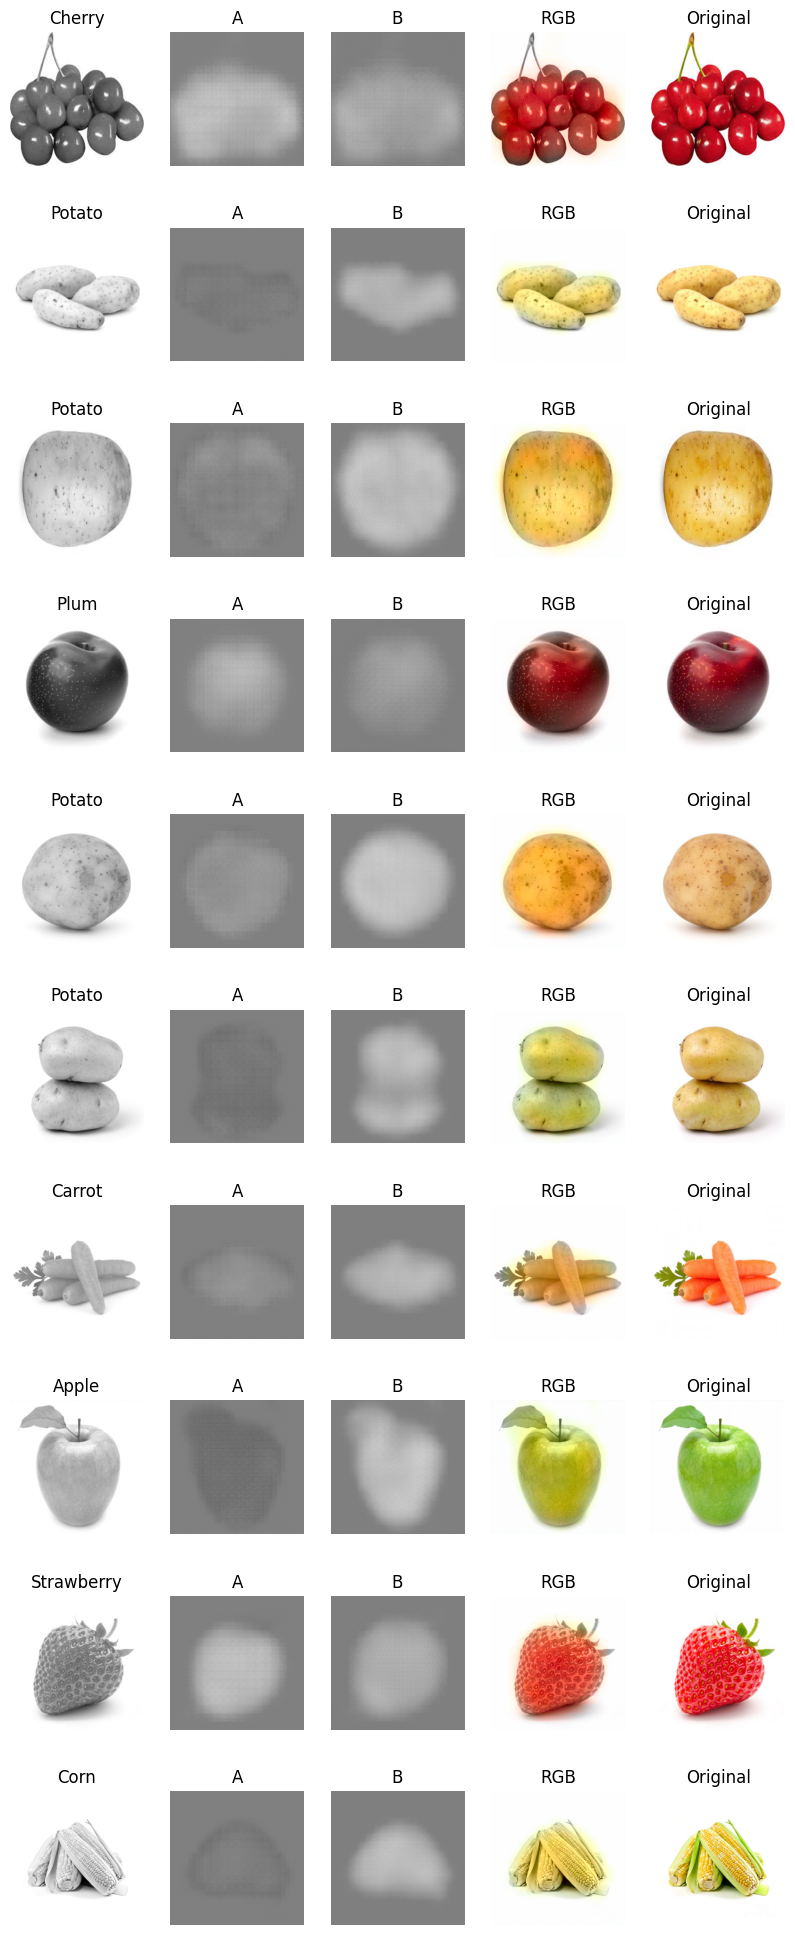

In [68]:
i, t, c, o = next(iter(test_loader))
recon = AE(i.to(device)).cpu().detach()
    
show_preds(i, recon, o, c, 10)